# Train Your Own Image Classifier

In this notebook you'll:
1. Download an image dataset from Kaggle
2. Train a convolutional neural network (CNN) to recognize the images
3. Test it on your own photos

Before you start: go to `Runtime → Change runtime type` and select **T4 GPU**. Training runs roughly 10x faster on a GPU.

Run each cell in order with the play button, or `Shift + Enter`.


## Step 1: Setup

Import the libraries we'll use.


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import kagglehub, os

print("TensorFlow version:", tf.__version__)
print("GPU available:", "Yes" if tf.config.list_physical_devices('GPU') else "No — go to Runtime → Change runtime type → T4 GPU")


TensorFlow version: 2.20.0
GPU available: Yes


## Step 2: Download a dataset from Kaggle

We'll use the Intel Image Classification dataset: about 25,000 photos across six categories — buildings, forests, glaciers, mountains, seas, and streets.

`kagglehub` downloads public Kaggle datasets in one line, with no account or API key required.

To use a different dataset, find one on [kaggle.com/datasets](https://www.kaggle.com/datasets), copy the part of the URL after `datasets/` (e.g. `username/dataset-name`), and paste it below. The dataset just needs its images sorted into one folder per category. List each labeled folder in `data_dirs` below; the notebook pools them together and splits them into train, validation, and test automatically. See the last section for details.


In [2]:
# Download the dataset (takes ~1 minute)
dataset_path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Dataset downloaded to:", dataset_path)
print("\nWhat's inside:")
for root, dirs, files in os.walk(dataset_path):
    depth = root.replace(dataset_path, "").count(os.sep)
    if depth <= 2:
        print("  " * depth + os.path.basename(root) + "/")


Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset downloaded to: /kaggle/input/intel-image-classification

What's inside:
intel-image-classification/
  seg_train/
    seg_train/
  seg_pred/
    seg_pred/
  seg_test/
    seg_test/


In [3]:
# This dataset ships TWO labeled folders (seg_train + seg_test). We pool them
# into one big pile, mix them together, then split into train / val / test.
# List every folder that contains your class subfolders — one or many.
data_dirs = [
    os.path.join(dataset_path, "seg_train", "seg_train"),
    os.path.join(dataset_path, "seg_test",  "seg_test"),
]
# 👆 If you swapped datasets: if yours has just ONE labeled folder, leave a single
#    path in this list. Check the printout below says the right class names!

IMG_SIZE = (128, 128)   # we shrink every image to 128x128 pixels
BATCH_SIZE = 32          # the model looks at 32 images at a time

# Count how many images we have — by listing files, WITHOUT decoding them.
# (Decoding all 17k images just to count them causes a big memory spike.)
exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif")
n_images = sum(
    f.lower().endswith(exts)
    for d in data_dirs for root, _, files in os.walk(d) for f in files
)

# Load each labeled folder
datasets = []
for d in data_dirs:
    ds = keras.utils.image_dataset_from_directory(
        d,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42,
    )
    datasets.append(ds)

class_names = datasets[0].class_names        # both folders have the same classes

# Join the folders into one dataset...
full_ds = datasets[0]
for d in datasets[1:]:
    full_ds = full_ds.concatenate(d)

full_ds = full_ds.unbatch().shuffle(min(n_images, 1000), seed=42, reshuffle_each_iteration=False).batch(BATCH_SIZE)

print("\n The model will learn to recognize:", class_names)

# Split into ~70% train, ~15% validation, ~15% test.
# The data is in batches; we hand out whole batches to each split.
# We keep at least 1 batch each for val and test so small datasets still work.
import math
n_batches = math.ceil(n_images / BATCH_SIZE)
n_val  = max(1, int(0.15 * n_batches))
n_test = max(1, int(0.15 * n_batches))

if n_val + n_test >= n_batches:
    raise ValueError(
        f"Only {n_batches} batch(es) of data — too few to split. "
        "Use a dataset with more images, or lower BATCH_SIZE."
    )

test_ds  = full_ds.take(n_test)                 # first chunk → test
val_ds   = full_ds.skip(n_test).take(n_val)     # next chunk → validation
train_ds = full_ds.skip(n_test + n_val)         # everything else → training


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(100, reshuffle_each_iteration=True).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

n_train = n_batches - n_val - n_test
print(f"\nPooled {n_images} images into {n_batches} batches, split into "
      f"{n_train} training, {n_val} validation, {n_test} test batches")


Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.

 The model will learn to recognize: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Pooled 17034 images into 533 batches, split into 375 training, 79 validation, 79 test batches


In [4]:
import os

for root, dirs, files in os.walk(dataset_path):
    imgs = [f for f in files if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".gif"))]
    depth = root.replace(dataset_path, "").count(os.sep)
    print("  " * depth + f"{os.path.basename(root) or root}/  [{len(imgs)} images, {len(dirs)} subfolders]")

intel-image-classification/  [0 images, 3 subfolders]
  seg_train/  [0 images, 1 subfolders]
    seg_train/  [0 images, 6 subfolders]
      mountain/  [2512 images, 0 subfolders]
      street/  [2382 images, 0 subfolders]
      buildings/  [2191 images, 0 subfolders]
      sea/  [2274 images, 0 subfolders]
      forest/  [2271 images, 0 subfolders]
      glacier/  [2404 images, 0 subfolders]
  seg_pred/  [0 images, 1 subfolders]
    seg_pred/  [7301 images, 0 subfolders]
  seg_test/  [0 images, 1 subfolders]
    seg_test/  [0 images, 6 subfolders]
      mountain/  [525 images, 0 subfolders]
      street/  [501 images, 0 subfolders]
      buildings/  [437 images, 0 subfolders]
      sea/  [510 images, 0 subfolders]
      forest/  [474 images, 0 subfolders]
      glacier/  [553 images, 0 subfolders]


## Step 3: Look at the data

Always look at your data before training. Here are a few of the images the model will learn from.


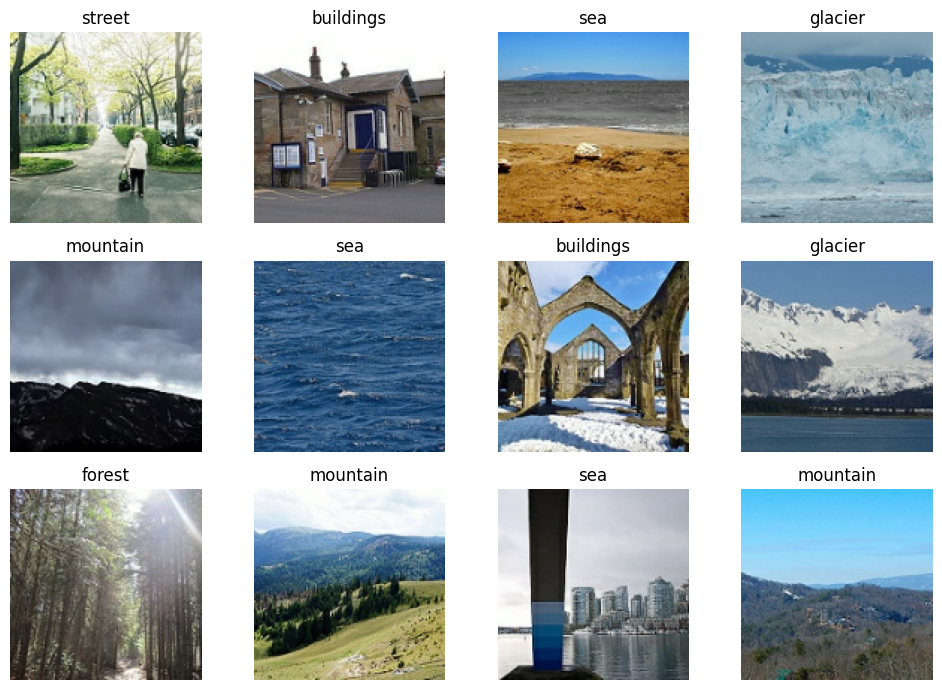

In [5]:
plt.figure(figsize=(10, 7))
for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()


## Step 4: Build the CNN

A convolutional neural network learns patterns in images:
- Early layers detect simple features like edges and colors
- Deeper layers combine those into larger structures like trees, windows, and waves
- The final layer decides which category the image belongs to

Each `Conv2D` layer is a set of pattern detectors. `MaxPooling2D` downsamples the image so the next layer works on a coarser view.


In [6]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),                    # convert pixel values 0-255 → 0-1

    layers.Conv2D(32, 3, activation="relu"),     # 32 pattern detectors
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),     # 64 more complex detectors
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),    # 128 even more complex detectors
    layers.MaxPooling2D(),

    layers.Flatten(),                            # unroll into one long list of features
    layers.Dropout(0.3),                         # randomly ignore some features → prevents memorizing
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),  # one output per category (probabilities)
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Train

The model passes over the training images repeatedly. Each full pass is called an epoch, and after each one it adjusts its pattern detectors to make fewer mistakes.

Watch the `accuracy` value as it trains. This takes about 3–5 minutes on a GPU.


In [7]:
EPOCHS = 8

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)


Epoch 1/8
    373/Unknown 45s 75ms/step - accuracy: 0.5259 - loss: 1.1975

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step - accuracy: 0.6150 - loss: 0.9979 - val_accuracy: 0.7362 - val_loss: 0.7223
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.7540 - loss: 0.6709 - val_accuracy: 0.7828 - val_loss: 0.6091
Epoch 3/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.8119 - loss: 0.5306 - val_accuracy: 0.7959 - val_loss: 0.5752
Epoch 4/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.8480 - loss: 0.4207 - val_accuracy: 0.8200 - val_loss: 0.5309
Epoch 5/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.8810 - loss: 0.3367 - val_accuracy: 0.8078 - val_loss: 0.5744
Epoch 6/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.9031 - loss: 0.2749 - val_accuracy: 0.8161 - val_loss: 0.5000
Epoch 7/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.9264 - loss: 0.2105 - val_accuracy: 0.8461 - val_loss: 0.4679
Epoch 8/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.9432 - loss: 0.1642 - val_accuracy: 0.84

## Step 6: How did training go?

- **accuracy** — how well the model does on images it trained on
- **val_accuracy** — how well it does on images it hasn't seen; this is the number that matters

If accuracy keeps rising while val_accuracy flattens or drops, the model is memorizing the training data rather than learning general patterns. This is called overfitting.


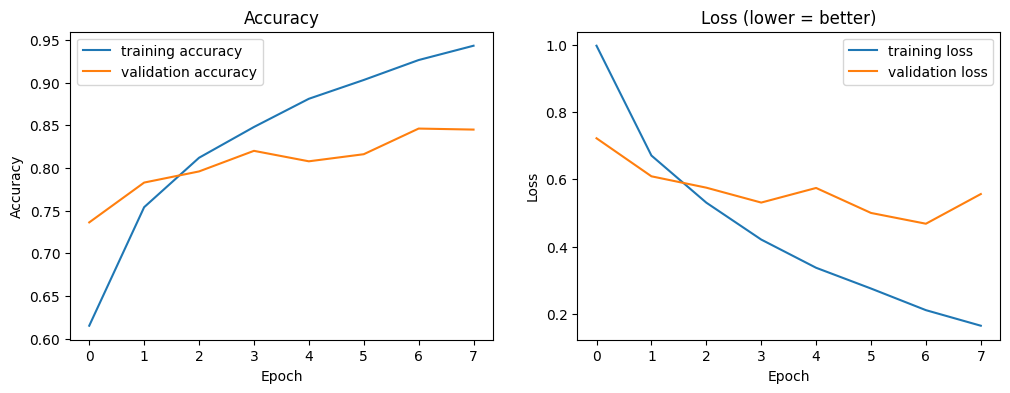


Final accuracy on new test images: 82.1%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="training accuracy")
ax1.plot(history.history["val_accuracy"], label="validation accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy"); ax1.legend(); ax1.set_title("Accuracy")

ax2.plot(history.history["loss"], label="training loss")
ax2.plot(history.history["val_loss"], label="validation loss")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.legend(); ax2.set_title("Loss (lower = better)")

plt.show()

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nFinal accuracy on new test images: {test_acc:.1%}")


## Step 7: Where does the model get confused?

A confusion matrix shows every prediction the model made on the test set. The diagonal is correct predictions; everything off the diagonal is a mistake.

Look for patterns. Does it confuse glaciers with mountains, or buildings with streets? Consider why that might happen.


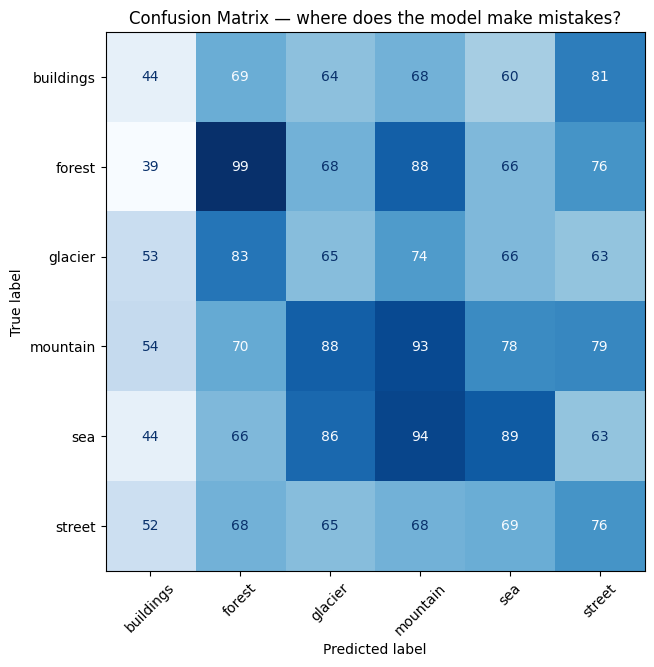

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.xticks(rotation=45)
plt.title("Confusion Matrix — where does the model make mistakes?")
plt.show()


## Step 8: Test it with your own image

Run the cell below, click **Choose Files**, and upload any photo. The model will report which category it predicts and how confident it is about each one.

Note that the model can only choose among the categories it was trained on. If you upload a photo of a dog, it will still pick one of the six scene types, usually with low confidence — a useful reminder that a model can't recognize things it was never shown.

Run the cell again any time to try another image.


In [ ]:
from google.colab import files
from PIL import Image
import io

uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    # Load and prepare the image the same way the training images were prepared
    img = Image.open(io.BytesIO(file_bytes)).convert("RGB")
    img_resized = img.resize(IMG_SIZE)
    img_array = np.expand_dims(np.array(img_resized), axis=0)  # add batch dimension

    # Ask the model for its prediction
    probs = model.predict(img_array, verbose=0)[0]
    best = np.argmax(probs)

    # Show the image and the model's confidence for each class
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.imshow(img)
    ax1.axis("off")
    ax1.set_title(f"Prediction: {class_names[best].upper()}\n({probs[best]:.0%} confident)")

    colors = ["#4CAF50" if i == best else "#B0BEC5" for i in range(len(class_names))]
    ax2.barh(class_names, probs, color=colors)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel("Confidence")
    ax2.set_title("Confidence by category")
    for i, p in enumerate(probs):
        ax2.text(p + 0.01, i, f"{p:.0%}", va="center")

    plt.tight_layout()
    plt.show()


## Step 9: Live demo — drag and drop an image

This cell builds a small interactive app inside the notebook. Drag a photo in, click to browse, or paste from the clipboard, and it classifies the image right away — no need to re-run cells between images.

The app also prints a public link. You can open it on your phone, take a photo, and classify it from there.

As before, the model can only pick from the six categories it was trained on. Show it something outside those and it will still choose one of them, usually with low confidence.


In [ ]:
!pip install gradio -q

import gradio as gr
import numpy as np

def classify(img):
    if img is None:
        return None

    img_resized = img.convert("RGB").resize(IMG_SIZE)
    arr = np.expand_dims(np.array(img_resized), axis=0).astype("float32")

    probs = model.predict(arr, verbose=0)[0]

    # Gradio shows this as a ranked confidence bar chart
    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

demo = gr.Interface(
    fn=classify,
    inputs=gr.Image(type="pil", label="Drop your photo here", sources=["upload", "clipboard", "webcam"]),
    outputs=gr.Label(num_top_classes=6, label="Predictions"),
    title="Scene Classifier",
    description="Upload a photo to classify it. This model only knows six categories: buildings, forest, glacier, mountain, sea, and street. Anything outside those will still be sorted into one of them.",
    flagging_mode="never",
)

demo.launch(share=True, debug=False)


## Bonus: Use any Kaggle image dataset

To train on something else — cats vs dogs, flowers, hand signs — follow these steps.

**1. Find a dataset** on [kaggle.com/datasets](https://www.kaggle.com/datasets). Searching for a topic plus "image classification" works well.

**2. Check the folder structure.** The dataset needs images sorted into one folder per category:
```
dataset/
  cats/
  dogs/
  hamsters/
```
Use the "Data" tab on the Kaggle page to see how it's organized.

**3. Update two things in Step 2:**
- Replace `"puneet6060/intel-image-classification"` with your dataset's ID (the part of the URL after `/datasets/`)
- Set `data_dir` to the folder that directly contains your category folders.

That's the only change. You don't need a separate test folder — the notebook takes all the images and splits them into train, validation, and test on its own. If your dataset came with separate `train/` and `test/` folders, point `data_dir` at whichever one holds the class folders, or at the parent that holds them all.

**4. Run everything again** from the top. The code adapts to however many categories your dataset has.

Check the printout after the loading cell. The class names it lists should be the things you want to tell apart, like `['cats', 'dogs']`. If you see something like `['train', 'test']`, you pointed one level too high — go one folder deeper.

### Experiment ideas
- Change `EPOCHS`. What happens with 2? With 20?
- Change `IMG_SIZE` to (64, 64). Is it faster? Less accurate? Why?
- Remove the `Dropout` layer and watch the gap between training and validation accuracy grow.
- Upload harder images: a painting of a forest, a snowy street, a photo of your classroom.
- Change the split from 70/15/15 to 50/25/25. Does less training data hurt accuracy?
